# Day-Ahead Trading Strategy

This notebook simulates a Day-Ahead trading strategy for a photovoltaic portfolio operating in the Italian electricity market.

The strategy uses solar generation forecasts to define market positions and evaluates how forecast errors affect traded volumes, imbalance exposure, and gross Day-Ahead revenues.

In particular, this notebook covers:

- loading market prices and solar generation forecasts
- defining Day-Ahead traded volumes
- comparing forecast and actual generation
- calculating forecast-driven imbalances
- estimating revenue impact under Day-Ahead market prices

## Configuration

In [96]:
from pathlib import Path

RAW_DATA_DIR = "../data/raw"
PROCESSED_DATA_DIR = "../data/processed"

MARKET_FILE = "../data/processed/italian_market_prices_2023.csv"
FORECAST_FILE = "../data/processed/solar_generation_forecast_2023.csv"
OUTPUT_FILE = "../data/processed/day_ahead_trading_results.csv"

## Imports

In [97]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from src.data_loader import (
    load_market_data,
    load_forecast_data
)
from src.trading import (
    align_forecast_timestamps,
    merge_market_and_forecast_data,
    create_day_ahead_position,
    calculate_imbalances,
    calculate_day_ahead_revenue
)
from src.metrics import quality_report

## Load Data

The Day-Ahead market price dataset and the solar generation forecast dataset are loaded and prepared for trading analysis.

Market prices represent the economic value of electricity, while the generation forecast represents the volume offered in the Day-Ahead market.

### Timestamp Alignment

PVGIS provides hourly photovoltaic generation estimates with timestamps referenced at 10 minutes past each hour (e.g., 00:10, 01:10).

To ensure consistency with the Italian Day-Ahead market data, which uses hourly timestamps (00:00, 01:00, ...), the photovoltaic timestamps are aligned to the beginning of each hour before merging the datasets.

In [98]:
market_df = load_market_data(MARKET_FILE)

print(market_df.head())

forecast_df = load_forecast_data(FORECAST_FILE)
forecast_df = align_forecast_timestamps(forecast_df)

print(forecast_df.head())

             datetime   price  hour  month
0 2023-01-01 00:00:00  195.90     0      1
1 2023-01-01 01:00:00  191.09     1      1
2 2023-01-01 02:00:00  187.95     2      1
3 2023-01-01 03:00:00  187.82     3      1
4 2023-01-01 04:00:00  187.74     4      1
             datetime  actual  forecast
0 2023-10-01 00:00:00     0.0       0.0
1 2023-10-01 01:00:00     0.0       0.0
2 2023-10-01 02:00:00     0.0       0.0
3 2023-10-01 03:00:00     0.0       0.0
4 2023-10-01 04:00:00     0.0       0.0


## Merge Market and Forecast Data

The market and generation datasets are merged on the hourly timestamp.

This creates a single trading dataset containing market prices, actual generation, and forecast generation.

In [99]:
trading_df = merge_market_and_forecast_data(
    forecast_df,
    market_df
)

trading_df.head()

,datetime,actual,forecast,price,hour,month
0,2023-10-01 00:00:00,0.0,0.0,107.81,0,10
1,2023-10-01 01:00:00,0.0,0.0,105.81,1,10
2,2023-10-01 02:00:00,0.0,0.0,104.61,2,10
3,2023-10-01 03:00:00,0.0,0.0,95.18,3,10
4,2023-10-01 04:00:00,0.0,0.0,95.18,4,10


In [100]:
trading_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  2209 non-null   datetime64[ns]
 1   actual    2209 non-null   float64       
 2   forecast  2209 non-null   float64       
 3   price     2209 non-null   float64       
 4   hour      2209 non-null   int64         
 5   month     2209 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 103.7 KB


## Trading Dataset Quality Checks

Basic checks are performed to verify that the merged trading dataset contains the expected observations and no missing values.

In [101]:
quality_report(trading_df)

trading_df.describe()

Rows: 2209

Missing values:
datetime    0
actual      0
forecast    0
price       0
hour        0
month       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  2209 non-null   datetime64[ns]
 1   actual    2209 non-null   float64       
 2   forecast  2209 non-null   float64       
 3   price     2209 non-null   float64       
 4   hour      2209 non-null   int64         
 5   month     2209 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 103.7 KB


,datetime,actual,forecast,price,hour,month
count,2209,2209.000000,2209.000000,2209.000000,2209.000000,2209.000000
mean,2023-11-15 23:18:55.898596608,13.489923,13.890264,123.844677,11.494794,10.999547
min,2023-10-01 00:00:00,0.000000,0.000000,2.456320,0.000000,10.000000
25%,2023-10-24 00:00:00,0.000000,0.000000,107.190000,5.000000,10.000000
50%,2023-11-15 23:00:00,0.000000,0.000000,123.370000,11.000000,11.000000
75%,2023-12-08 23:00:00,18.577000,18.785380,140.580000,17.000000,12.000000
max,2023-12-31 23:00:00,82.347000,78.982220,240.000000,23.000000,12.000000
std,NaN,22.966473,23.682245,29.963185,6.926510,0.821198


### Dataset Validation

The merged trading dataset contains no missing values and includes all the information required for the subsequent trading and revenue analysis.

## Day-Ahead Position Definition

In a Day-Ahead trading workflow, the trader submits a market position based on expected renewable generation.

In this simulation, the Day-Ahead position is assumed to be equal to the forecast photovoltaic generation. Actual generation is then compared with the traded position to quantify forecast-driven imbalances.

In [102]:
trading_df = create_day_ahead_position(trading_df)
trading_df = calculate_imbalances(trading_df)

trading_df.head()

,datetime,actual,forecast,price,hour,month,day_ahead_position,imbalance,absolute_imbalance
0,2023-10-01 00:00:00,0.0,0.0,107.81,0,10,0.0,0.0,0.0
1,2023-10-01 01:00:00,0.0,0.0,105.81,1,10,0.0,0.0,0.0
2,2023-10-01 02:00:00,0.0,0.0,104.61,2,10,0.0,0.0,0.0
3,2023-10-01 03:00:00,0.0,0.0,95.18,3,10,0.0,0.0,0.0
4,2023-10-01 04:00:00,0.0,0.0,95.18,4,10,0.0,0.0,0.0


### Imbalance Convention

A positive imbalance means that actual generation was higher than the Day-Ahead position, while a negative imbalance means that actual generation was lower than the traded position.

In [103]:
trading_df[
    trading_df["actual"] > 0
][[
    "datetime",
    "actual",
    "forecast",
    "day_ahead_position",
    "imbalance",
    "price"
]].head(20)

,datetime,actual,forecast,day_ahead_position,imbalance,price
5,2023-10-01 05:00:00,0.791,1.06923,1.06923,-0.27823,99.00000
6,2023-10-01 06:00:00,19.299,21.34863,21.34863,-2.04963,104.61000
7,2023-10-01 07:00:00,42.062,43.60861,43.60861,-1.54661,104.61000
8,2023-10-01 08:00:00,60.748,60.40323,60.40323,0.34477,103.94000
9,2023-10-01 09:00:00,72.725,73.61020,73.61020,-0.88520,96.32000
10,2023-10-01 10:00:00,77.287,78.20283,78.20283,-0.91583,83.22000
11,2023-10-01 11:00:00,75.910,78.93404,78.93404,-3.02404,85.01000
12,2023-10-01 12:00:00,69.127,70.29115,70.29115,-1.16415,81.71000
13,2023-10-01 13:00:00,57.275,64.89734,64.89734,-7.62234,31.00000
14,2023-10-01 14:00:00,41.266,47.37252,47.37252,-6.10652,15.00000


## Imbalance Analysis

Forecast errors create differences between actual photovoltaic generation and the Day-Ahead traded position.

These differences are referred to as imbalances and represent the volume exposure that must be managed after the Day-Ahead market clearing.

In [104]:
print(f"Average imbalance: {trading_df['imbalance'].mean():.2f} kW")
print(f"Average absolute imbalance: {trading_df['absolute_imbalance'].mean():.2f} kW")
print(f"Maximum positive imbalance: {trading_df['imbalance'].max():.2f} kW")
print(f"Maximum negative imbalance: {trading_df['imbalance'].min():.2f} kW")

Average imbalance: -0.40 kW
Average absolute imbalance: 1.06 kW
Maximum positive imbalance: 15.30 kW
Maximum negative imbalance: -14.88 kW


## Forecast Error Distribution

Forecast errors determine the difference between the Day-Ahead traded position and the actual photovoltaic generation.

Understanding the distribution of forecast errors is essential because it provides insight into how frequently the portfolio deviates from its scheduled market position and the typical magnitude of these deviations.

A forecast error centered around zero indicates that the forecasting model is approximately unbiased, while the spread of the distribution reflects the operational uncertainty faced by the trader.

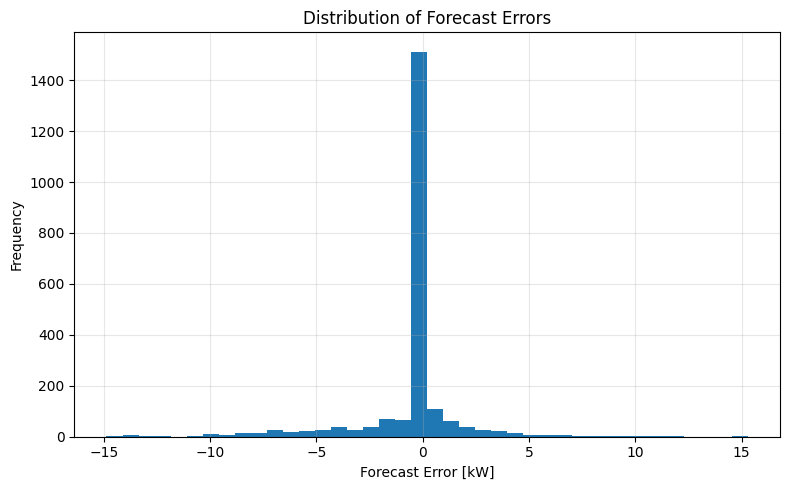

In [105]:
plt.figure(figsize=(8,5))
plt.hist(
    trading_df["imbalance"],
    bins=40
)
plt.title("Distribution of Forecast Errors")
plt.xlabel("Forecast Error [kW]")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Trading Insight

The forecast error distribution is strongly centered around zero, indicating that the forecasting model does not exhibit a significant systematic bias.

Most forecast errors are relatively small, while larger deviations occur less frequently and correspond to periods of rapidly changing weather conditions. These larger forecast errors are the primary source of imbalance risk for photovoltaic market participants.

## Intraday Forecast Error Profile

Forecast accuracy is not constant throughout the day.

By analysing the average absolute forecast error for each hour, it is possible to identify the periods during which photovoltaic generation is more difficult to predict and therefore more exposed to imbalance risk.

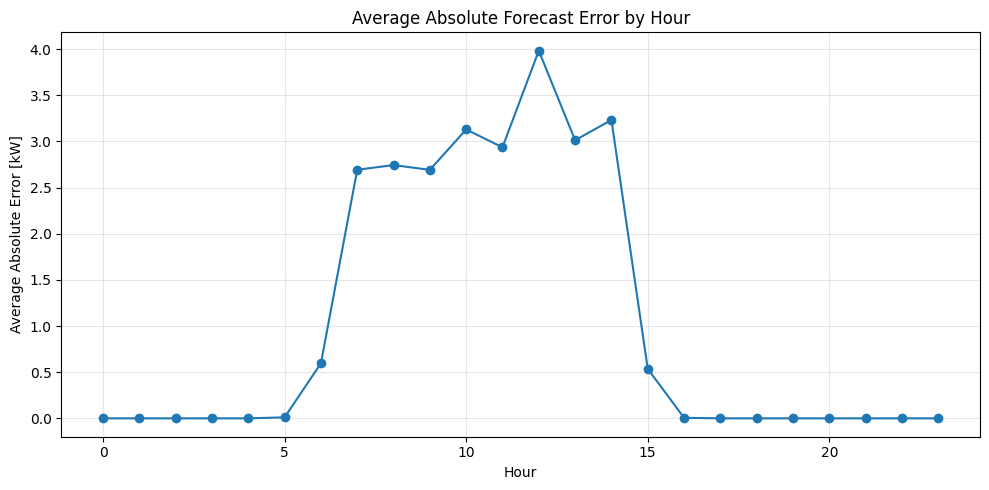

In [106]:
hourly_imbalance = (
    trading_df
    .groupby("hour")["absolute_imbalance"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(
    hourly_imbalance.index,
    hourly_imbalance.values,
    marker="o"
)
plt.title("Average Absolute Forecast Error by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Absolute Error [kW]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Operational Insight

Forecast errors are concentrated during daylight hours, when photovoltaic generation is active and weather variability directly affects power production.

The largest average errors occur around midday, when photovoltaic output reaches its highest levels. During nighttime hours, forecast errors are effectively zero because both forecast and actual generation are equal to zero.

These results indicate that trading risk is concentrated during periods of active solar production, highlighting the importance of accurate weather forecasts for renewable energy market participation.

## Day-Ahead Revenue Simulation

In the Day-Ahead electricity market, renewable producers submit their expected generation before delivery.

For simplicity, this simulation assumes that the Day-Ahead market accepts the forecast generation as the traded energy volume.

Revenue is therefore calculated using:

- the forecast generation as the traded volume;
- the Day-Ahead market price for each hour.

The difference between forecast and actual generation represents the imbalance exposure, which will be analysed separately.

In [107]:
trading_df = calculate_day_ahead_revenue(trading_df)

trading_df.head()

,datetime,actual,forecast,price,hour,month,day_ahead_position,imbalance,absolute_imbalance,day_ahead_revenue
0,2023-10-01 00:00:00,0.0,0.0,107.81,0,10,0.0,0.0,0.0,0.0
1,2023-10-01 01:00:00,0.0,0.0,105.81,1,10,0.0,0.0,0.0,0.0
2,2023-10-01 02:00:00,0.0,0.0,104.61,2,10,0.0,0.0,0.0,0.0
3,2023-10-01 03:00:00,0.0,0.0,95.18,3,10,0.0,0.0,0.0,0.0
4,2023-10-01 04:00:00,0.0,0.0,95.18,4,10,0.0,0.0,0.0,0.0


## Revenue Summary

The total simulated Day-Ahead revenue is computed together with basic descriptive statistics.

In [108]:
total_revenue = trading_df["day_ahead_revenue"].sum()
average_hourly_revenue = trading_df["day_ahead_revenue"].mean()
max_hourly_revenue = trading_df["day_ahead_revenue"].max()

average_market_price = trading_df["price"].mean()
total_forecast_generation = trading_df["forecast"].sum()
total_actual_generation = trading_df["actual"].sum()

print(f"Total Day-Ahead revenue: €{total_revenue:,.2f}")
print(f"Average hourly revenue: €{average_hourly_revenue:,.2f}")
print(f"Maximum hourly revenue: €{max_hourly_revenue:,.2f}")
print(f"Average market price: €{average_market_price:.2f}/MWh")
print(f"Total forecast generation: {total_forecast_generation:,.0f} kWh")
print(f"Total actual generation: {total_actual_generation:,.0f} kWh")

Total Day-Ahead revenue: €3,744,146.91
Average hourly revenue: €1,694.95
Maximum hourly revenue: €12,814.99
Average market price: €123.84/MWh
Total forecast generation: 30,684 kWh
Total actual generation: 29,799 kWh


## Revenue Profile

The hourly revenue profile reflects the combined effect of photovoltaic generation and market prices throughout the analysis period.

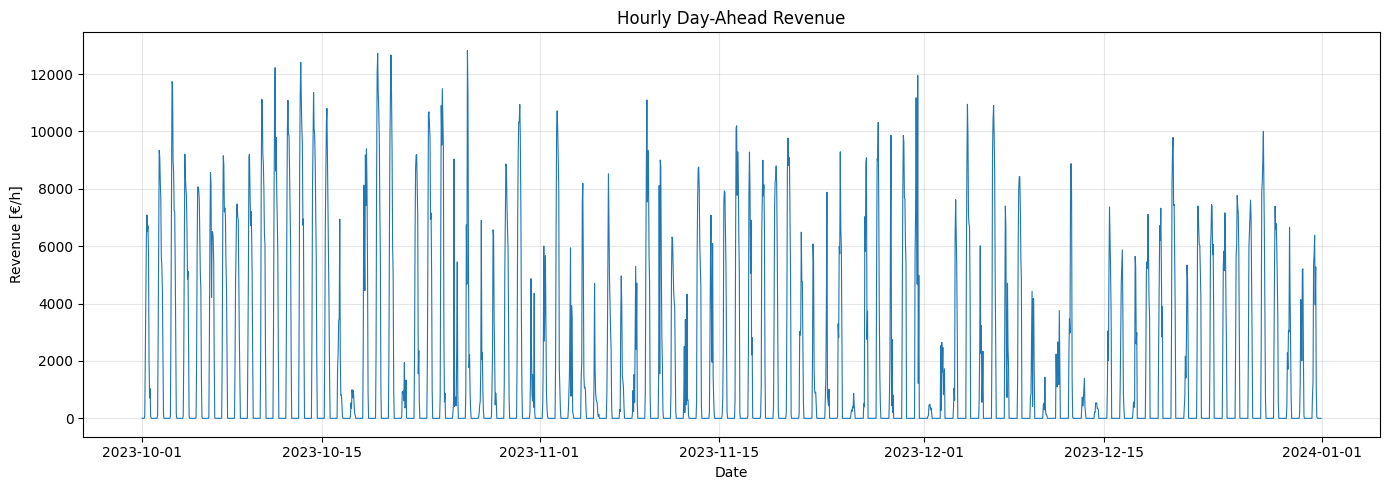

In [109]:
plt.figure(figsize=(14,5))
plt.plot(
    trading_df["datetime"],
    trading_df["day_ahead_revenue"],
    linewidth=0.8
)
plt.title("Hourly Day-Ahead Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue [€/h]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Revenue Insight

The simulated Day-Ahead strategy generated approximately **€3.74 million** of revenue over the analysed period, with an average hourly revenue of around **€1,695** and peak hourly revenues exceeding **€12,800**.

Revenue is driven by the interaction between forecast photovoltaic generation and market prices. The highest revenues occur when elevated solar production coincides with high electricity prices, while revenues naturally fall to zero during nighttime hours when no generation is available.

It is important to note that these revenues represent the **gross Day-Ahead market income** based on the forecast generation submitted to the market. The financial impact of forecast errors and imbalance settlements is not included at this stage and will be analysed separately in the following notebook.

## Monthly Day-Ahead Revenue

Monthly revenues provide a clearer view of the seasonal evolution of trading income by aggregating hourly revenues over each month.

This representation highlights how seasonal changes in photovoltaic generation influence the economic performance of the trading strategy.

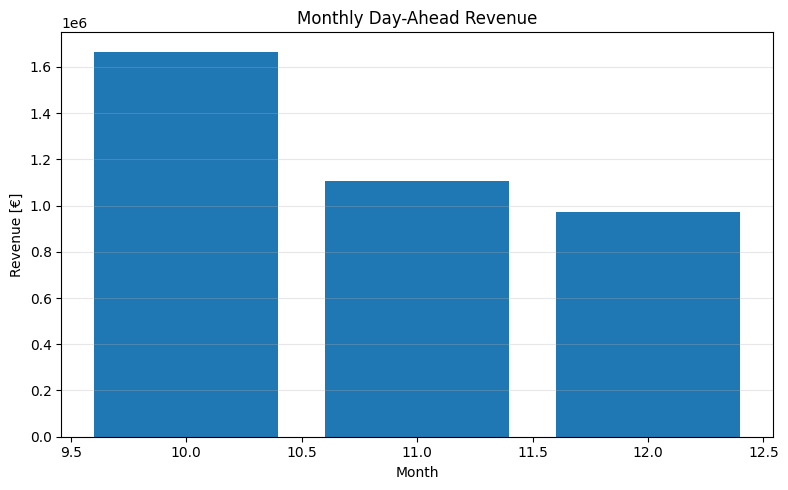

In [110]:
monthly_revenue = (
    trading_df
    .groupby("month")["day_ahead_revenue"]
    .sum()
)

plt.figure(figsize=(8,5))
plt.bar(
    monthly_revenue.index,
    monthly_revenue.values
)
plt.title("Monthly Day-Ahead Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue [€]")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../images/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Seasonal Perspective

Monthly Day-Ahead revenue decreases progressively from October to December, primarily due to the seasonal reduction in photovoltaic generation during autumn and early winter.

Although electricity prices remain relatively high during this period, the shorter daylight hours and lower solar irradiation reduce the amount of energy available for trading.

This seasonal behavior highlights that renewable trading revenues depend not only on market prices but also on the underlying generation profile of the asset.

---

## Key Findings

This notebook demonstrated how photovoltaic generation forecasts can be translated into a simple Day-Ahead trading strategy for the Italian electricity market.

1. Forecast photovoltaic generation was used to define the Day-Ahead traded position, while actual generation was used to evaluate the resulting imbalance.

2. Forecast errors remained relatively small on average, with an average absolute imbalance of approximately **1.1 kW**, indicating strong forecasting performance under simulated weather uncertainty.

3. Forecast errors were concentrated during daylight hours, particularly around midday when photovoltaic production reaches its highest levels, highlighting the periods of greatest operational risk.

4. The simulated Day-Ahead strategy generated approximately **€3.74 million** of gross revenue over the analysed period, with peak hourly revenues exceeding **€12,800**.

5. Monthly revenues decreased progressively from October to December, reflecting the seasonal reduction in solar generation despite relatively strong electricity prices.

6. The simulated revenues represent the gross Day-Ahead market income based on forecast generation and do not account for imbalance settlement costs or other market penalties.

The trading strategy developed in this notebook provides the input dataset for the final portfolio performance analysis developed in the next notebook, where profitability and portfolio performance metrics will be analysed in greater detail.

## Save Trading Dataset

The final trading dataset is exported for the portfolio performance and profitability analysis developed in the next notebook.

In [111]:
trading_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Trading dataset saved to {OUTPUT_FILE}")

Trading dataset saved to ../data/processed/day_ahead_trading_results.csv
